# 02 Profitability Analysis & Segmentation

**Context:**
Notebook 01 established the empirical ground truth: the catalog is heavily reliant on discounting (94%+), operational failure is standard (>57% late deliveries), and top-line revenue frequently masks margin destruction.

**Purpose:**
This notebook translates those observations into actionable segmentation. I will classify products into operational quadrants, quantify the exact dollar impact of "Revenue Traps," evaluate profit concentration, and build a composite risk score to prioritize executive action.

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Load ground truth master
csv_path = '../data/processed/ground_truth_master.csv'
df = pd.read_csv(csv_path)

print(f"Dataframe loaded: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataframe loaded: 118 rows, 17 columns.


## 2. SKU Quadrant Classification
Classify all products into four operational quadrants based on their relationship to the catalog median for net profit percentage and late delivery risk. Revenue scale is represented by bubble size to visually identify "Revenue Traps" (large bubbles in the Cut Candidates quadrant) without distorting the operational axes.

*Note: The 46 products with fewer than 100 orders (excluded per DL-010) will be tagged as 'Excluded (Low Volume)' and omitted from this specific visual, as their delivery risk rates are statistically invalid.*

In [2]:
# Calculate Medians (excluding nulls automatically)
median_margin = df['net_profit_pct'].median()
median_risk = df['late_delivery_risk_rate'].median()

print(f"Catalog Median Margin: {median_margin:.2%}")
print(f"Catalog Median Delivery Risk: {median_risk:.2%}")

# Define Quadrant Logic
def assign_quadrant(row):
    if pd.isna(row['late_delivery_risk_rate']):
        return 'Excluded (Low Volume)'
        
    if row['net_profit_pct'] >= median_margin and row['late_delivery_risk_rate'] < median_risk:
        return 'Cash Generators'
    elif row['net_profit_pct'] >= median_margin and row['late_delivery_risk_rate'] >= median_risk:
        return 'Operational Risks'
    elif row['net_profit_pct'] < median_margin and row['late_delivery_risk_rate'] < median_risk:
        return 'Underperformers'
    elif row['net_profit_pct'] < median_margin and row['late_delivery_risk_rate'] >= median_risk:
        return 'Cut Candidates'
    else:
        return 'Unknown'

# Apply classification
df['quadrant'] = df.apply(assign_quadrant, axis=1)

# Summary counts
print("\n--- QUADRANT DISTRIBUTION ---")
print(df['quadrant'].value_counts())

Catalog Median Margin: 11.11%
Catalog Median Delivery Risk: 57.75%

--- QUADRANT DISTRIBUTION ---
quadrant
Operational Risks    32
Underperformers      31
Cut Candidates       28
Cash Generators      27
Name: count, dtype: int64


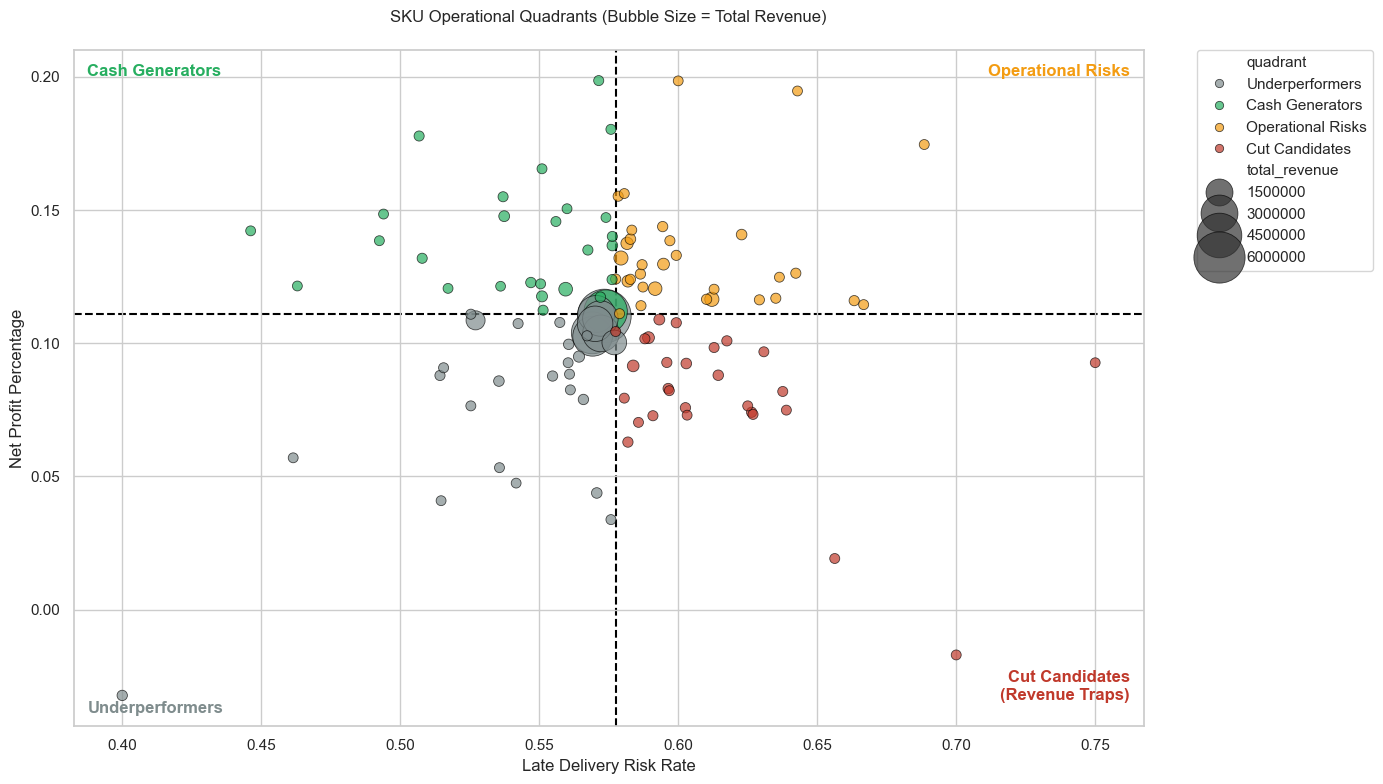

In [6]:
# Filter out excluded items for the plot (safety step)
plot_df = df[df['quadrant'] != 'Excluded (Low Volume)']

plt.figure(figsize=(14, 8))

# Create bubble chart
sns.scatterplot(
    data=plot_df, 
    x='late_delivery_risk_rate', 
    y='net_profit_pct', 
    size='total_revenue', 
    sizes=(50, 1500), 
    hue='quadrant',
    palette={
        'Cash Generators': '#27ae60', 
        'Operational Risks': '#f39c12', 
        'Underperformers': '#7f8c8d', 
        'Cut Candidates': '#c0392b'
    },
    alpha=0.7,
    edgecolor='black'
)

# Add median threshold lines
plt.axvline(median_risk, color='black', linestyle='--', linewidth=1.5, zorder=0)
plt.axhline(median_margin, color='black', linestyle='--', linewidth=1.5, zorder=0)

# Quadrant Labels (dynamically positioned near corners)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(x_min + 0.005, y_max - 0.01, 'Cash Generators', color='#27ae60', fontsize=12, fontweight='bold', ha='left')
plt.text(x_max - 0.005, y_max - 0.01, 'Operational Risks', color='#f39c12', fontsize=12, fontweight='bold', ha='right')
plt.text(x_min + 0.005, y_min + 0.005, 'Underperformers', color='#7f8c8d', fontsize=12, fontweight='bold', ha='left')
plt.text(x_max - 0.005, y_min + 0.01, 'Cut Candidates\n(Revenue Traps)', color='#c0392b', fontsize=12, fontweight='bold', ha='right')

plt.title('SKU Operational Quadrants (Bubble Size = Total Revenue)', pad=20)
plt.xlabel('Late Delivery Risk Rate')
plt.ylabel('Net Profit Percentage')

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

**Business Interpretation:**
* **The Scale Illusion:** The largest bubbles (top revenue generators) are clustered tightly around the crosshairs of the medians. The business has not scaled its most efficient or reliable products; it has simply pumped massive volume into profoundly average SKUs. 
* **The "Cut Candidates" Bleed:** There are 28 products sitting in the bottom-right quadrant (below median margin, above median delivery risk). These products combine weak unit economics with active operational failure. 
* **Balanced Distribution:** The catalog splits almost perfectly evenly across the four quadrants. This confirms my decision to use medians (DL-011) was correct, it effectively neutralized the severe right-skew of the volume outliers and established a realistic internal baseline for performance.